# Importing the Data
### CelebA Dataset 

We will be utilizing the CelebA dataset for this exploration \
Pixels values will be normalized from [0,255] -> [-1, 1] \
This is done to work in conjunction with the Generator's tanh activation output \

In [1]:
import torchvision.transforms as transforms

# mean and std of channels
mean = [0.5, 0.5, 0.5] # [R,G,B]
std = [0.5, 0.5, 0.5] # [R,G,B]

transform = transforms.Compose([
    transforms.CenterCrop((178, 178)),
    transforms.Resize((64, 64)),
    transforms.ToTensor(), # pixel values go from [0,255] to [0,1]
    transforms.Normalize(
        mean=mean,
        std=std
    ) # pixel values go from [0,1] to [-1,1]
])

In [2]:
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_dataset = CelebA(root='../data', split='train', transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


# Defining the Model

### Generator : 
Input: a latent z of dimension noise_dim (assume gaussian distribution) \
Output : A proposed image

### Discriminator
Input: a proposed image, namely the output G(z) \
Output : A binary classification label 
* '1' : The discriminator predicts that the image comes from distribution pdata (image is part of training set) 
* '0' : The dicrimimator predicts that the image comes from distribution pG (image was generated by Generator) 

### Goal 
The minimax game has achieved optimality when: 

$pG(x) = pData(x)$ (Optimal generator for optimal D) \
$DG(x) = \frac{pdata(x)}{pdata(x) + pG(x)} = 0.5$ (Discriminator is guessing)

In [3]:
import torch.nn as nn 

LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 1024, 4, 1, 0, bias=False),
            nn.BatchNorm2d(1024), 
            nn.ReLU(), 

            nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False), 
            nn.BatchNorm2d(512), 
            nn.ReLU(), 

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False), 
            nn.BatchNorm2d(256), 
            nn.ReLU(), 

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), 
            nn.BatchNorm2d(128), 
            nn.ReLU(), 

            # [B, C, H, W] : [B, 3, 64, 64]
            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False), 
            nn.Tanh()
        )

    def forward(self, z):
        y = self.model(z)
        return y

In [4]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # P(Y=1|x) = D(x) = sigmoid(f(x))
        # we will use BCEWithLogitsLoss below, because it is more numerically stable than using a plain Sigmoid followed by a BCELoss
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False), 
            nn.LeakyReLU(0.2, inplace=True), 

            nn.Conv2d(64, 128, 4, 2, 1, bias=False), 
            nn.BatchNorm2d(128), 
            nn.LeakyReLU(0.2, inplace=True), 

            nn.Conv2d(128, 256, 4, 2, 1, bias=False), 
            nn.BatchNorm2d(256), 
            nn.LeakyReLU(0.2, inplace=True), 

            nn.Conv2d(256, 512, 4, 2, 1, bias=False), 
            nn.BatchNorm2d(512), 
            nn.LeakyReLU(0.2, inplace=True),

            # No sigmoid applied
            nn.Conv2d(512, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x):
        y = self.model(x)
        return y.view(x.size(0), 1)

In [5]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt

def generate_and_save_images(model, epoch, noise):
    Path("../data/dcgan").mkdir(parents=True, exist_ok=True)

    model.eval()
    with torch.no_grad():
        fake_images = model(noise).cpu() # [-1, 1]
        fake_images = (fake_images.clamp(-1, 1) + 1) / 2 # [0, 1]

        fig = plt.figure(figsize = (4,4))
        for i in range(fake_images.size(0)):
            plt.subplot(4, 4, i + 1)

            image = fake_images[i].permute(1,2,0) # [C, H, W] -> [H, W, C]
            plt.imshow(image)
            plt.axis('off')

        plt.savefig(f"../data/dcgan/image_at_epoch_{epoch+1:04d}.png")
        plt.show()
        
    model.train()

In [7]:
import torch

def train_gan(generator,
              discriminator,
              generator_optimizer, 
              discriminator_optimizer, 
              train_loader, 
              device, 
              latent_dim=100, 
              num_epochs=50, 
              loss_function=nn.BCEWithLogitsLoss(), 
              fixed_noise=None,
              ):
    for epoch in range(num_epochs):
        for i, data in enumerate(train_loader):
            real_images, _ = data
            real_images = real_images.to(device)

            # ------  train discriminator on real data ------
            discriminator_optimizer.zero_grad()                        # zero out the gradients from the previous batch
            real_labels = torch.ones(real_images.size(0), 1, device=device) # (B, 1) -> '1' for each image in the batch
            real_outputs = discriminator(real_images)
            real_loss = loss_function(real_outputs, real_labels)
            real_loss.backward()                                       # computes weight updates for real images

            # ------ train discriminator on fake data ------
            z = torch.randn(real_images.size(0), latent_dim, 1, 1, device=device)
            fake_images = generator(z)
            fake_labels = torch.zeros(real_images.size(0), 1, device=device) # (B, 1) -> '0' for every img in the batch
            fake_outputs = discriminator(fake_images.detach())          # detach does not propagate gradients back through G
            fake_loss = loss_function(fake_outputs, fake_labels)
            fake_loss.backward()
            discriminator_optimizer.step()

            # ------ train the generator on the real data ------
            generator_optimizer.zero_grad()
            fake_labels = torch.ones(real_images.size(0), 1, device=device)  # # (B, 1) -> '1' for each image in the batch
            fake_outputs = discriminator(fake_images)                   # D(G(z))
            gen_loss = loss_function(fake_outputs, fake_labels)         # BCE(D(G(z)), 1) : B/C generator ideally wants to fool discriminator
            gen_loss.backward()
            generator_optimizer.step()

            if i % 100 == 0:
                print(f"Epoch [{epoch+1} / {num_epochs}], Step [{i + 1} / {len(train_loader)}] ,"
                      f"Discriminator Loss : {real_loss.item() + fake_loss.item():.4f}"
                      f"Generator Loss : {gen_loss.item():.4f}")
                
        if fixed_noise is not None:
            generate_and_save_images(generator, epoch, fixed_noise)


Epoch [1 / 50], Step [1 / 2544] ,Discriminator Loss : 1.9388Generator Loss : 19.8907
Epoch [1 / 50], Step [101 / 2544] ,Discriminator Loss : 0.2012Generator Loss : 7.9261
Epoch [1 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0116Generator Loss : 9.9971
Epoch [1 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0000Generator Loss : 15.3854
Epoch [1 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0224Generator Loss : 15.6598
Epoch [1 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0283Generator Loss : 17.1279
Epoch [1 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0102Generator Loss : 8.4214
Epoch [1 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0072Generator Loss : 8.9597
Epoch [1 / 50], Step [801 / 2544] ,Discriminator Loss : 0.3337Generator Loss : 18.0593
Epoch [1 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0060Generator Loss : 7.7374
Epoch [1 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.6540Generator Loss : 6.5514
Epoch [1 / 50], Step [1101 / 2544] ,Discriminator 

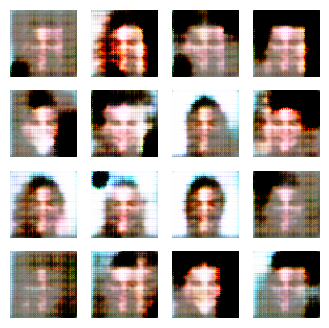

Epoch [2 / 50], Step [1 / 2544] ,Discriminator Loss : 0.3601Generator Loss : 4.7243
Epoch [2 / 50], Step [101 / 2544] ,Discriminator Loss : 0.1511Generator Loss : 6.2480
Epoch [2 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0636Generator Loss : 8.7138
Epoch [2 / 50], Step [301 / 2544] ,Discriminator Loss : 0.4945Generator Loss : 6.4223
Epoch [2 / 50], Step [401 / 2544] ,Discriminator Loss : 0.4914Generator Loss : 6.8336
Epoch [2 / 50], Step [501 / 2544] ,Discriminator Loss : 0.1380Generator Loss : 6.0218
Epoch [2 / 50], Step [601 / 2544] ,Discriminator Loss : 0.1972Generator Loss : 8.5553
Epoch [2 / 50], Step [701 / 2544] ,Discriminator Loss : 0.4425Generator Loss : 9.9828
Epoch [2 / 50], Step [801 / 2544] ,Discriminator Loss : 0.3199Generator Loss : 10.8013
Epoch [2 / 50], Step [901 / 2544] ,Discriminator Loss : 0.5727Generator Loss : 9.8939
Epoch [2 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.2239Generator Loss : 8.7338
Epoch [2 / 50], Step [1101 / 2544] ,Discriminator Loss

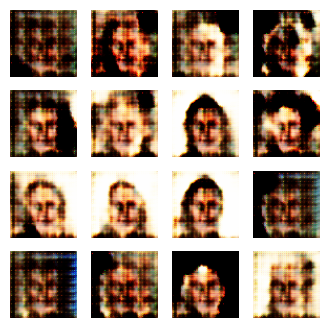

Epoch [3 / 50], Step [1 / 2544] ,Discriminator Loss : 0.1908Generator Loss : 8.7933
Epoch [3 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0438Generator Loss : 9.9450
Epoch [3 / 50], Step [201 / 2544] ,Discriminator Loss : 0.1324Generator Loss : 4.1886
Epoch [3 / 50], Step [301 / 2544] ,Discriminator Loss : 0.1176Generator Loss : 8.4371
Epoch [3 / 50], Step [401 / 2544] ,Discriminator Loss : 0.1505Generator Loss : 6.1217
Epoch [3 / 50], Step [501 / 2544] ,Discriminator Loss : 0.1898Generator Loss : 9.0382
Epoch [3 / 50], Step [601 / 2544] ,Discriminator Loss : 0.2713Generator Loss : 8.3700
Epoch [3 / 50], Step [701 / 2544] ,Discriminator Loss : 0.3690Generator Loss : 9.5999
Epoch [3 / 50], Step [801 / 2544] ,Discriminator Loss : 0.1027Generator Loss : 6.7326
Epoch [3 / 50], Step [901 / 2544] ,Discriminator Loss : 0.2874Generator Loss : 11.9183
Epoch [3 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0649Generator Loss : 5.6625
Epoch [3 / 50], Step [1101 / 2544] ,Discriminator Loss

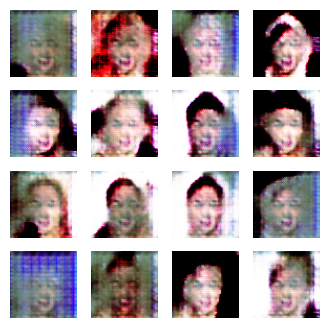

Epoch [4 / 50], Step [1 / 2544] ,Discriminator Loss : 0.4345Generator Loss : 4.9212
Epoch [4 / 50], Step [101 / 2544] ,Discriminator Loss : 0.1799Generator Loss : 6.7232
Epoch [4 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0602Generator Loss : 8.3356
Epoch [4 / 50], Step [301 / 2544] ,Discriminator Loss : 0.4639Generator Loss : 9.1313
Epoch [4 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0452Generator Loss : 7.2330
Epoch [4 / 50], Step [501 / 2544] ,Discriminator Loss : 0.3896Generator Loss : 9.4238
Epoch [4 / 50], Step [601 / 2544] ,Discriminator Loss : 0.2968Generator Loss : 8.6417
Epoch [4 / 50], Step [701 / 2544] ,Discriminator Loss : 0.1490Generator Loss : 5.4448
Epoch [4 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0548Generator Loss : 5.4613
Epoch [4 / 50], Step [901 / 2544] ,Discriminator Loss : 0.1002Generator Loss : 7.8791
Epoch [4 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0739Generator Loss : 13.2150
Epoch [4 / 50], Step [1101 / 2544] ,Discriminator Loss

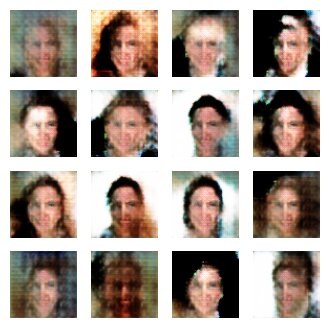

Epoch [5 / 50], Step [1 / 2544] ,Discriminator Loss : 0.1482Generator Loss : 7.2245
Epoch [5 / 50], Step [101 / 2544] ,Discriminator Loss : 0.1134Generator Loss : 8.9234
Epoch [5 / 50], Step [201 / 2544] ,Discriminator Loss : 0.1153Generator Loss : 7.5754
Epoch [5 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0481Generator Loss : 6.5439
Epoch [5 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0564Generator Loss : 6.5358
Epoch [5 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0264Generator Loss : 9.3327
Epoch [5 / 50], Step [601 / 2544] ,Discriminator Loss : 0.7642Generator Loss : 9.8617
Epoch [5 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0163Generator Loss : 6.5627
Epoch [5 / 50], Step [801 / 2544] ,Discriminator Loss : 0.1941Generator Loss : 6.7181
Epoch [5 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0912Generator Loss : 7.5378
Epoch [5 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.4671Generator Loss : 6.1276
Epoch [5 / 50], Step [1101 / 2544] ,Discriminator Loss 

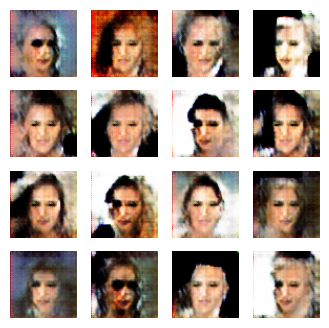

Epoch [6 / 50], Step [1 / 2544] ,Discriminator Loss : 0.6162Generator Loss : 5.8173
Epoch [6 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0319Generator Loss : 7.0121
Epoch [6 / 50], Step [201 / 2544] ,Discriminator Loss : 0.3758Generator Loss : 9.9012
Epoch [6 / 50], Step [301 / 2544] ,Discriminator Loss : 0.3306Generator Loss : 9.8010
Epoch [6 / 50], Step [401 / 2544] ,Discriminator Loss : 0.1568Generator Loss : 6.1995
Epoch [6 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0044Generator Loss : 11.9958
Epoch [6 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0189Generator Loss : 13.6726
Epoch [6 / 50], Step [701 / 2544] ,Discriminator Loss : 0.3404Generator Loss : 9.0638
Epoch [6 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0419Generator Loss : 8.0361
Epoch [6 / 50], Step [901 / 2544] ,Discriminator Loss : 0.4081Generator Loss : 9.4995
Epoch [6 / 50], Step [1001 / 2544] ,Discriminator Loss : 1.0984Generator Loss : 5.4897
Epoch [6 / 50], Step [1101 / 2544] ,Discriminator Los

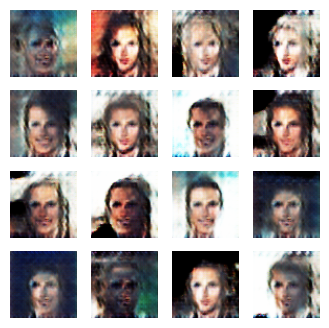

Epoch [7 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0113Generator Loss : 6.0737
Epoch [7 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0795Generator Loss : 5.9458
Epoch [7 / 50], Step [201 / 2544] ,Discriminator Loss : 0.1249Generator Loss : 9.6949
Epoch [7 / 50], Step [301 / 2544] ,Discriminator Loss : 0.1920Generator Loss : 13.7359
Epoch [7 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0267Generator Loss : 6.9576
Epoch [7 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0461Generator Loss : 8.8524
Epoch [7 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0896Generator Loss : 7.1308
Epoch [7 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0363Generator Loss : 8.3290
Epoch [7 / 50], Step [801 / 2544] ,Discriminator Loss : 0.1197Generator Loss : 6.3291
Epoch [7 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0355Generator Loss : 8.1368
Epoch [7 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0617Generator Loss : 7.9656
Epoch [7 / 50], Step [1101 / 2544] ,Discriminator Loss

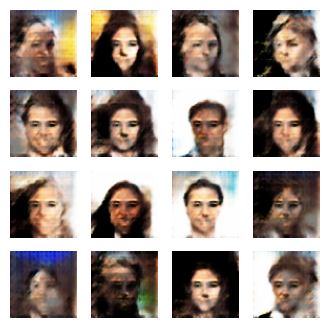

Epoch [8 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0111Generator Loss : 9.1822
Epoch [8 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0175Generator Loss : 9.1594
Epoch [8 / 50], Step [201 / 2544] ,Discriminator Loss : 0.3058Generator Loss : 6.5082
Epoch [8 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0292Generator Loss : 9.7698
Epoch [8 / 50], Step [401 / 2544] ,Discriminator Loss : 0.1508Generator Loss : 7.1328
Epoch [8 / 50], Step [501 / 2544] ,Discriminator Loss : 0.2911Generator Loss : 8.0675
Epoch [8 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0713Generator Loss : 6.8412
Epoch [8 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0354Generator Loss : 11.1934
Epoch [8 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0262Generator Loss : 10.4921
Epoch [8 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0911Generator Loss : 9.1205
Epoch [8 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.1847Generator Loss : 6.9103
Epoch [8 / 50], Step [1101 / 2544] ,Discriminator Los

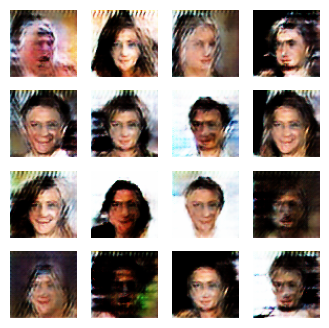

Epoch [9 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0669Generator Loss : 11.2236
Epoch [9 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0817Generator Loss : 9.5020
Epoch [9 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0783Generator Loss : 8.6978
Epoch [9 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0516Generator Loss : 14.6669
Epoch [9 / 50], Step [401 / 2544] ,Discriminator Loss : 0.1137Generator Loss : 7.0367
Epoch [9 / 50], Step [501 / 2544] ,Discriminator Loss : 0.1620Generator Loss : 2.7274
Epoch [9 / 50], Step [601 / 2544] ,Discriminator Loss : 0.1160Generator Loss : 4.8731
Epoch [9 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0537Generator Loss : 6.6941
Epoch [9 / 50], Step [801 / 2544] ,Discriminator Loss : 0.3746Generator Loss : 9.1985
Epoch [9 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0064Generator Loss : 12.3801
Epoch [9 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.1709Generator Loss : 5.8863
Epoch [9 / 50], Step [1101 / 2544] ,Discriminator Lo

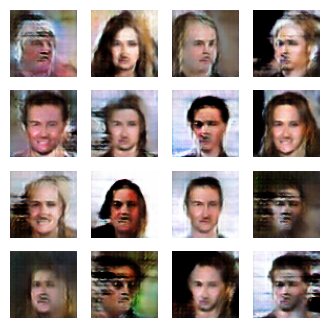

Epoch [10 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0258Generator Loss : 9.3329
Epoch [10 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0298Generator Loss : 8.7885
Epoch [10 / 50], Step [201 / 2544] ,Discriminator Loss : 0.1974Generator Loss : 9.7357
Epoch [10 / 50], Step [301 / 2544] ,Discriminator Loss : 0.1120Generator Loss : 7.9081
Epoch [10 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0280Generator Loss : 9.0791
Epoch [10 / 50], Step [501 / 2544] ,Discriminator Loss : 0.3123Generator Loss : 8.4733
Epoch [10 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0456Generator Loss : 6.8842
Epoch [10 / 50], Step [701 / 2544] ,Discriminator Loss : 0.3134Generator Loss : 6.3699
Epoch [10 / 50], Step [801 / 2544] ,Discriminator Loss : 0.1695Generator Loss : 5.7393
Epoch [10 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0444Generator Loss : 8.1703
Epoch [10 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0134Generator Loss : 8.1599
Epoch [10 / 50], Step [1101 / 2544] ,Discrim

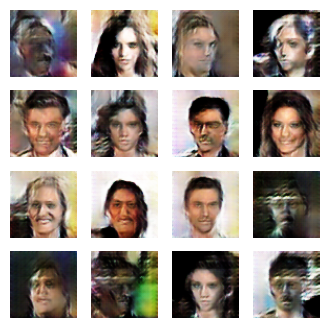

Epoch [11 / 50], Step [1 / 2544] ,Discriminator Loss : 0.1044Generator Loss : 6.2946
Epoch [11 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0682Generator Loss : 7.6632
Epoch [11 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0779Generator Loss : 5.2679
Epoch [11 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0889Generator Loss : 10.5832
Epoch [11 / 50], Step [401 / 2544] ,Discriminator Loss : 0.1140Generator Loss : 4.2303
Epoch [11 / 50], Step [501 / 2544] ,Discriminator Loss : 0.1101Generator Loss : 6.1961
Epoch [11 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0888Generator Loss : 4.7120
Epoch [11 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0635Generator Loss : 7.0416
Epoch [11 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0169Generator Loss : 10.5272
Epoch [11 / 50], Step [901 / 2544] ,Discriminator Loss : 0.2611Generator Loss : 5.4255
Epoch [11 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.1152Generator Loss : 7.8212
Epoch [11 / 50], Step [1101 / 2544] ,Discr

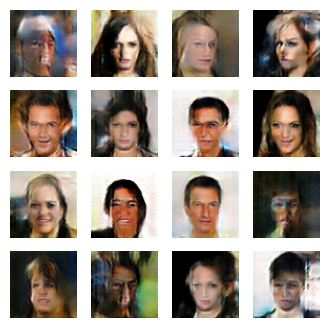

Epoch [12 / 50], Step [1 / 2544] ,Discriminator Loss : 0.2041Generator Loss : 5.0158
Epoch [12 / 50], Step [101 / 2544] ,Discriminator Loss : 0.1038Generator Loss : 8.2641
Epoch [12 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0819Generator Loss : 10.4418
Epoch [12 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0924Generator Loss : 6.5111
Epoch [12 / 50], Step [401 / 2544] ,Discriminator Loss : 0.1138Generator Loss : 5.7102
Epoch [12 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0525Generator Loss : 8.3995
Epoch [12 / 50], Step [601 / 2544] ,Discriminator Loss : 0.1199Generator Loss : 6.7129
Epoch [12 / 50], Step [701 / 2544] ,Discriminator Loss : 0.1958Generator Loss : 6.6557
Epoch [12 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0116Generator Loss : 8.7792
Epoch [12 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0251Generator Loss : 9.8438
Epoch [12 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.6877Generator Loss : 3.4688
Epoch [12 / 50], Step [1101 / 2544] ,Discri

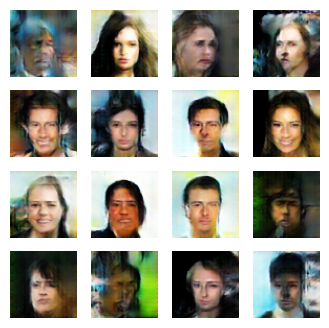

Epoch [13 / 50], Step [1 / 2544] ,Discriminator Loss : 0.3991Generator Loss : 9.2707
Epoch [13 / 50], Step [101 / 2544] ,Discriminator Loss : 0.2265Generator Loss : 6.6166
Epoch [13 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0172Generator Loss : 7.1996
Epoch [13 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0296Generator Loss : 10.6755
Epoch [13 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0883Generator Loss : 8.8329
Epoch [13 / 50], Step [501 / 2544] ,Discriminator Loss : 0.1366Generator Loss : 5.9515
Epoch [13 / 50], Step [601 / 2544] ,Discriminator Loss : 0.4448Generator Loss : 7.1691
Epoch [13 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0224Generator Loss : 9.7968
Epoch [13 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0485Generator Loss : 10.5880
Epoch [13 / 50], Step [901 / 2544] ,Discriminator Loss : 0.1455Generator Loss : 7.5113
Epoch [13 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0275Generator Loss : 8.2455
Epoch [13 / 50], Step [1101 / 2544] ,Discr

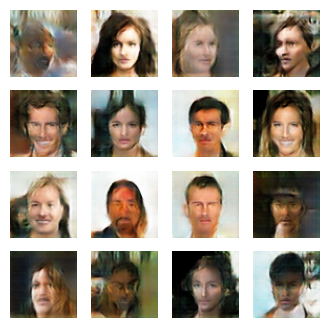

Epoch [14 / 50], Step [1 / 2544] ,Discriminator Loss : 0.9007Generator Loss : 11.7596
Epoch [14 / 50], Step [101 / 2544] ,Discriminator Loss : 0.4518Generator Loss : 11.6975
Epoch [14 / 50], Step [201 / 2544] ,Discriminator Loss : 0.2613Generator Loss : 7.3976
Epoch [14 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0043Generator Loss : 8.5871
Epoch [14 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0839Generator Loss : 5.3475
Epoch [14 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0905Generator Loss : 7.2806
Epoch [14 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0385Generator Loss : 6.4339
Epoch [14 / 50], Step [701 / 2544] ,Discriminator Loss : 0.3571Generator Loss : 4.0010
Epoch [14 / 50], Step [801 / 2544] ,Discriminator Loss : 0.1460Generator Loss : 6.0694
Epoch [14 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0029Generator Loss : 6.9916
Epoch [14 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0686Generator Loss : 5.1327
Epoch [14 / 50], Step [1101 / 2544] ,Discr

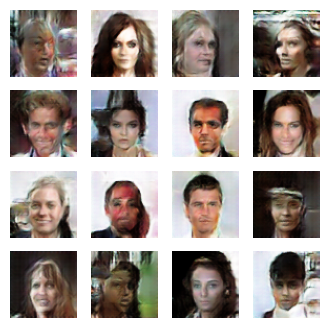

Epoch [15 / 50], Step [1 / 2544] ,Discriminator Loss : 0.1109Generator Loss : 5.1705
Epoch [15 / 50], Step [101 / 2544] ,Discriminator Loss : 0.1060Generator Loss : 8.0373
Epoch [15 / 50], Step [201 / 2544] ,Discriminator Loss : 0.2264Generator Loss : 4.6909
Epoch [15 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0097Generator Loss : 5.8215
Epoch [15 / 50], Step [401 / 2544] ,Discriminator Loss : 0.1035Generator Loss : 9.1810
Epoch [15 / 50], Step [501 / 2544] ,Discriminator Loss : 0.1675Generator Loss : 7.4317
Epoch [15 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0473Generator Loss : 5.9714
Epoch [15 / 50], Step [701 / 2544] ,Discriminator Loss : 0.3677Generator Loss : 6.3185
Epoch [15 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0967Generator Loss : 11.5526
Epoch [15 / 50], Step [901 / 2544] ,Discriminator Loss : 0.2033Generator Loss : 7.0233
Epoch [15 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.1101Generator Loss : 6.0841
Epoch [15 / 50], Step [1101 / 2544] ,Discri

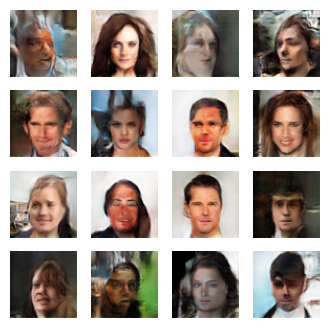

Epoch [16 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0750Generator Loss : 3.5225
Epoch [16 / 50], Step [101 / 2544] ,Discriminator Loss : 0.6210Generator Loss : 4.6394
Epoch [16 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0330Generator Loss : 10.5409
Epoch [16 / 50], Step [301 / 2544] ,Discriminator Loss : 0.2407Generator Loss : 6.6054
Epoch [16 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0728Generator Loss : 6.4405
Epoch [16 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0569Generator Loss : 8.4062
Epoch [16 / 50], Step [601 / 2544] ,Discriminator Loss : 0.1303Generator Loss : 15.1324
Epoch [16 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0394Generator Loss : 10.1606
Epoch [16 / 50], Step [801 / 2544] ,Discriminator Loss : 3.3209Generator Loss : 5.6267
Epoch [16 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0844Generator Loss : 8.5868
Epoch [16 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.1398Generator Loss : 4.4394
Epoch [16 / 50], Step [1101 / 2544] ,Disc

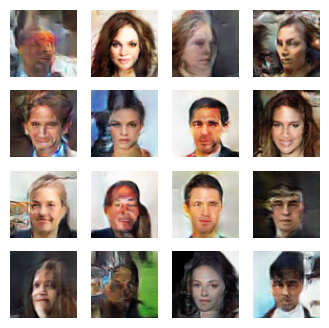

Epoch [17 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0724Generator Loss : 12.7977
Epoch [17 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0618Generator Loss : 6.1758
Epoch [17 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0020Generator Loss : 7.2205
Epoch [17 / 50], Step [301 / 2544] ,Discriminator Loss : 0.3584Generator Loss : 6.1713
Epoch [17 / 50], Step [401 / 2544] ,Discriminator Loss : 0.5311Generator Loss : 4.7549
Epoch [17 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0784Generator Loss : 7.1482
Epoch [17 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0757Generator Loss : 6.3602
Epoch [17 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0609Generator Loss : 8.2394
Epoch [17 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0672Generator Loss : 7.7773
Epoch [17 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0203Generator Loss : 9.4516
Epoch [17 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0335Generator Loss : 7.7410
Epoch [17 / 50], Step [1101 / 2544] ,Discri

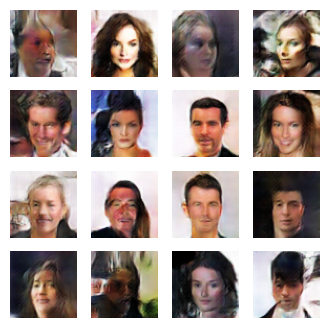

Epoch [18 / 50], Step [1 / 2544] ,Discriminator Loss : 0.2896Generator Loss : 4.3931
Epoch [18 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0324Generator Loss : 7.9737
Epoch [18 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0519Generator Loss : 10.8279
Epoch [18 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0252Generator Loss : 13.1229
Epoch [18 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0061Generator Loss : 12.7039
Epoch [18 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0742Generator Loss : 7.7715
Epoch [18 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0898Generator Loss : 2.4725
Epoch [18 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0834Generator Loss : 6.1910
Epoch [18 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0200Generator Loss : 7.1872
Epoch [18 / 50], Step [901 / 2544] ,Discriminator Loss : 0.2359Generator Loss : 4.8876
Epoch [18 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0473Generator Loss : 4.7262
Epoch [18 / 50], Step [1101 / 2544] ,Disc

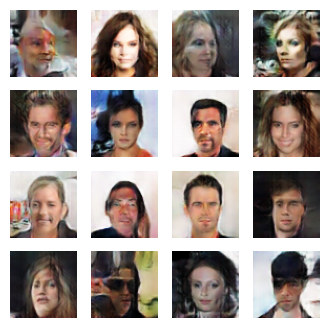

Epoch [19 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0894Generator Loss : 6.4421
Epoch [19 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0173Generator Loss : 6.5605
Epoch [19 / 50], Step [201 / 2544] ,Discriminator Loss : 0.1002Generator Loss : 3.3010
Epoch [19 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0044Generator Loss : 10.9746
Epoch [19 / 50], Step [401 / 2544] ,Discriminator Loss : 0.1624Generator Loss : 4.5353
Epoch [19 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0100Generator Loss : 8.0293
Epoch [19 / 50], Step [601 / 2544] ,Discriminator Loss : 0.1524Generator Loss : 3.8685
Epoch [19 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0564Generator Loss : 6.7999
Epoch [19 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0886Generator Loss : 5.9748
Epoch [19 / 50], Step [901 / 2544] ,Discriminator Loss : 0.1099Generator Loss : 9.7312
Epoch [19 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.4055Generator Loss : 4.0566
Epoch [19 / 50], Step [1101 / 2544] ,Discri

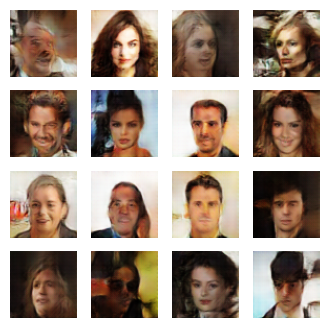

Epoch [20 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0775Generator Loss : 6.7205
Epoch [20 / 50], Step [101 / 2544] ,Discriminator Loss : 0.1066Generator Loss : 8.7021
Epoch [20 / 50], Step [201 / 2544] ,Discriminator Loss : 0.1121Generator Loss : 10.9339
Epoch [20 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0866Generator Loss : 8.5357
Epoch [20 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0092Generator Loss : 10.7270
Epoch [20 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0175Generator Loss : 8.0812
Epoch [20 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0694Generator Loss : 4.8872
Epoch [20 / 50], Step [701 / 2544] ,Discriminator Loss : 0.3046Generator Loss : 8.3942
Epoch [20 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0292Generator Loss : 8.7293
Epoch [20 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0083Generator Loss : 12.5383
Epoch [20 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0133Generator Loss : 6.5261
Epoch [20 / 50], Step [1101 / 2544] ,Disc

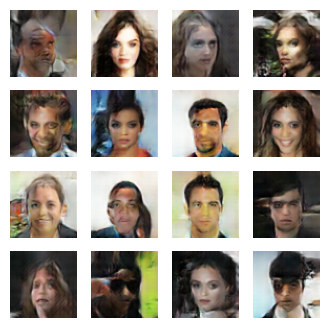

Epoch [21 / 50], Step [1 / 2544] ,Discriminator Loss : 0.1964Generator Loss : 8.8225
Epoch [21 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0611Generator Loss : 7.1656
Epoch [21 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0724Generator Loss : 4.7769
Epoch [21 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0312Generator Loss : 6.5397
Epoch [21 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0821Generator Loss : 6.5464
Epoch [21 / 50], Step [501 / 2544] ,Discriminator Loss : 0.1502Generator Loss : 10.8489
Epoch [21 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0765Generator Loss : 5.6606
Epoch [21 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0367Generator Loss : 5.2800
Epoch [21 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0980Generator Loss : 6.6901
Epoch [21 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0595Generator Loss : 4.5324
Epoch [21 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.1169Generator Loss : 5.3796
Epoch [21 / 50], Step [1101 / 2544] ,Discri

In [ ]:
NUM_EPOCHS = 50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = Generator(latent_dim=LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

# Apply the weights
generator.apply(weights_init)
discriminator.apply(weights_init)

generator_optimizer = torch.optim.AdamW(generator.parameters())
discriminator_optimizer = torch.optim.AdamW(discriminator.parameters())

fixed_noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)

train_gan(generator,
        discriminator,
        generator_optimizer, 
        discriminator_optimizer, 
        train_loader, 
        device, 
        latent_dim=100, 
        num_epochs=50, 
        loss_function=nn.BCEWithLogitsLoss(), 
        fixed_noise=fixed_noise
        )